In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [2]:
df = pd.read_csv("Telco_Customer_Churn_Dataset.csv")

sns.set_style("whitegrid")

In [5]:
def tenure_group(month):
    if month <= 12:
        return "0-12 Months"
    elif month <= 36:
        return "13-36 Months"
    else:
        return "37+ Months"

df["tenure_group"] = df["tenure"].apply(tenure_group)

print("_"*60)
print("TENURE GROUP DISTRIBUTION")
print("_"*60)
print(df["tenure_group"].value_counts())

____________________________________________________________
TENURE GROUP DISTRIBUTION
____________________________________________________________
tenure_group
37+ Months      3001
0-12 Months     2186
13-36 Months    1856
Name: count, dtype: int64


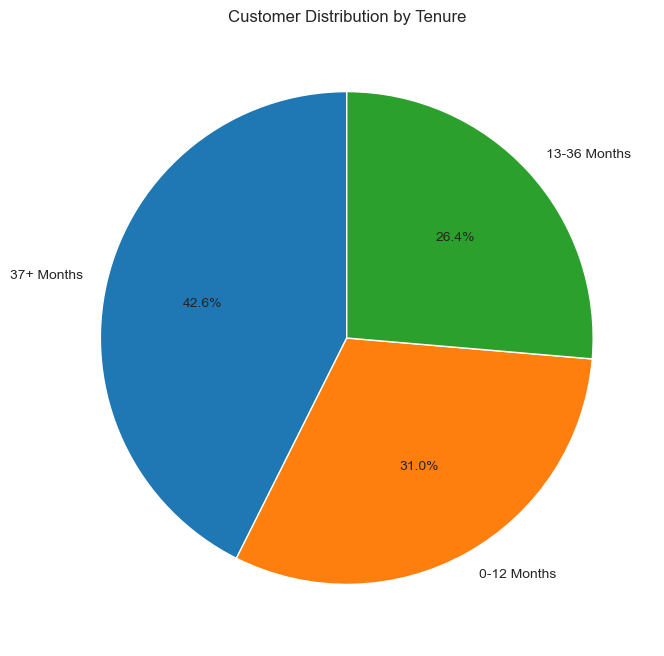

In [6]:
tenure_counts = df["tenure_group"].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    tenure_counts,
    labels=tenure_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Distribution by Tenure")
plt.show()

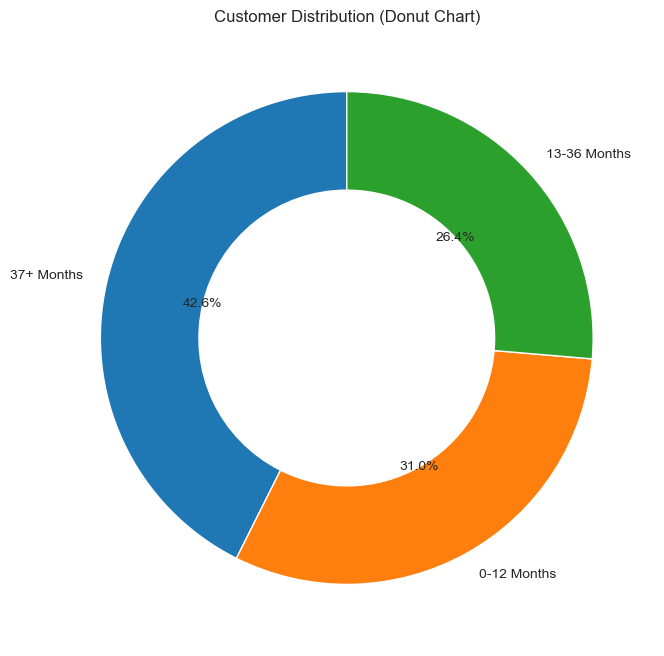

In [7]:
plt.figure(figsize=(8,8))

plt.pie(
    tenure_counts,
    labels=tenure_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.4}
)

plt.title("Customer Distribution (Donut Chart)")
plt.show()


In [9]:
avg_monthly = (
    df.groupby("tenure_group")["MonthlyCharges"]
    .mean()
    .reset_index()
)

print("\nAverage Monthly Charges")
print(avg_monthly)



Average Monthly Charges
   tenure_group  MonthlyCharges
0   0-12 Months       56.097781
1  13-36 Months       63.248195
2    37+ Months       72.008730


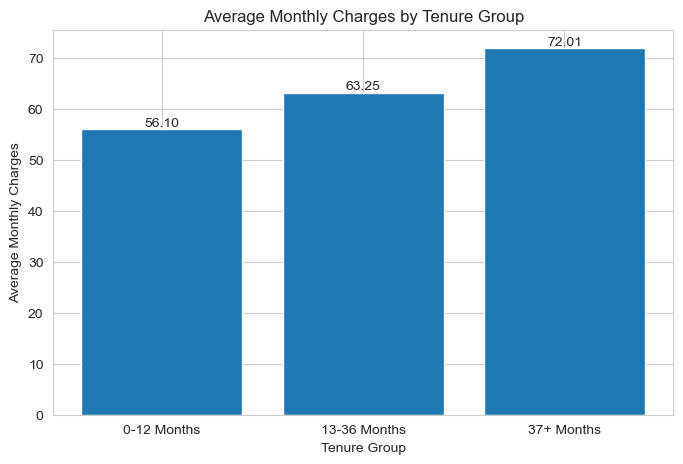

In [10]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    avg_monthly["tenure_group"],
    avg_monthly["MonthlyCharges"]
)

plt.title("Average Monthly Charges by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Average Monthly Charges")

# Add annotations
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.show()

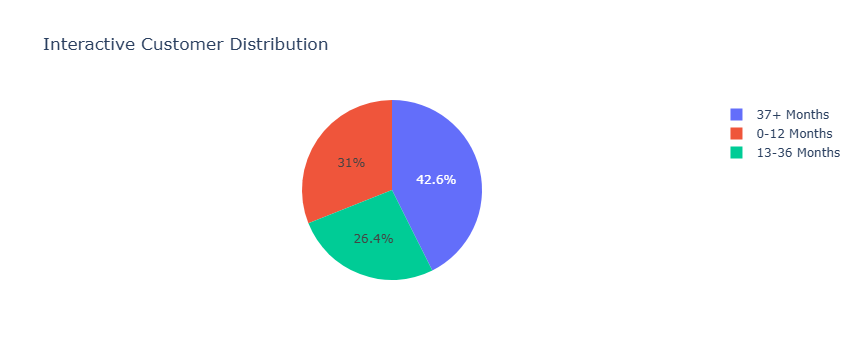

In [11]:
fig = px.pie(
    names=tenure_counts.index,
    values=tenure_counts.values,
    title="Interactive Customer Distribution"
)

fig.show()

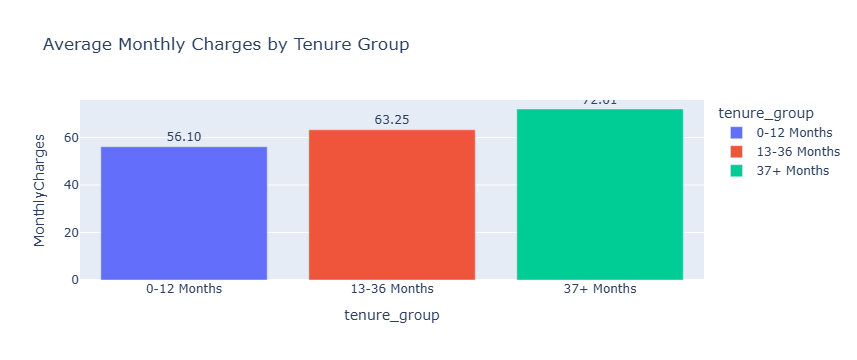

In [13]:
fig = px.bar(
    avg_monthly,
    x="tenure_group",
    y="MonthlyCharges",
    color="tenure_group",
    text="MonthlyCharges",
    title="Average Monthly Charges by Tenure Group"
)

fig.update_traces(texttemplate="%{text:.2f}",
                  textposition="outside")

fig.show()

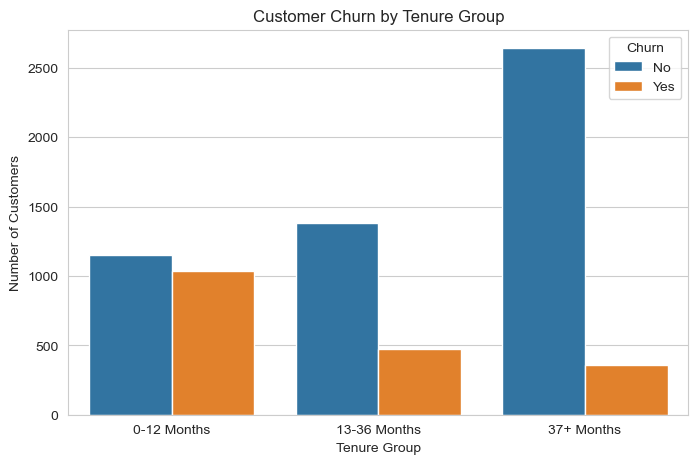

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="tenure_group",
    hue="Churn"
)

plt.title("Customer Churn by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Customers")

plt.show()

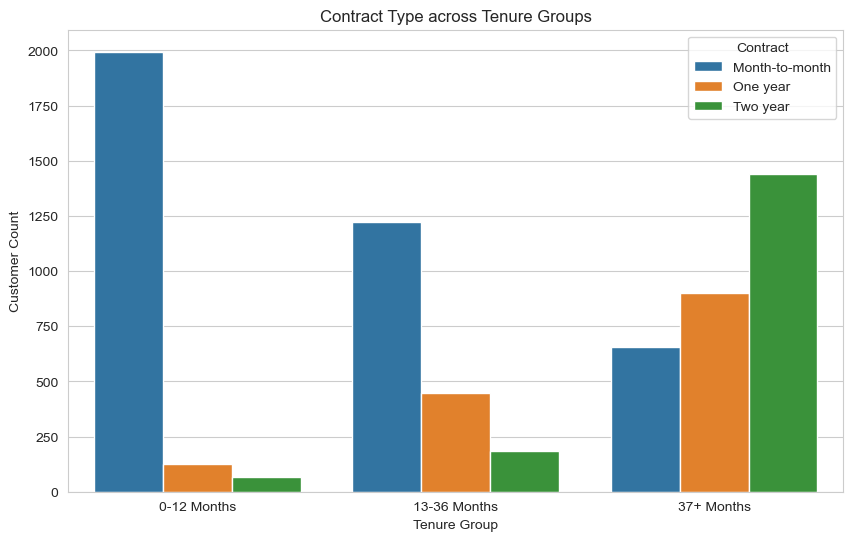


------------------------------------------------------------
CUSTOMER SEGMENTATION COMPLETED SUCCESSFULLY
------------------------------------------------------------


In [16]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="tenure_group",
    hue="Contract"
)

plt.title("Contract Type across Tenure Groups")
plt.xlabel("Tenure Group")
plt.ylabel("Customer Count")

plt.show()

print("\n" + "-"*60)
print("CUSTOMER SEGMENTATION COMPLETED SUCCESSFULLY")
print("-"*60)